In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("online+retail/Online Retail.xlsx")

# Basic inspection
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

C:\Users\prade\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       ----------

In [2]:
# Check missing values
df.isnull().sum()

# Drop rows with no CustomerID (critical field)
df = df.dropna(subset=['CustomerID'])

# Fill Description if needed
df['Description'] = df['Description'].fillna('Unknown')

In [3]:
df.duplicated().sum()

df = df.drop_duplicates()

In [4]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int)

In [5]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [6]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [8]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour
df['Weekday'] = df['InvoiceDate'].dt.day_name()

In [9]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [10]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [11]:
# Recency (lower is better → reverse labels)
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    q=4,
    labels=[4,3,2,1],
    duplicates='drop'
)

# Frequency (higher is better)
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

# Monetary (higher is better)
rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

In [12]:
country_sales = df.groupby('Country')['TotalPrice'].sum().reset_index()

In [13]:
product_sales = df.groupby('Description').agg({
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).sort_values(by='TotalPrice', ascending=False)

In [14]:
df_cleaned = df.copy()
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday


In [15]:
df_cleaned.to_csv("cleaned_online_retail.csv", index=False)
rfm.to_csv("rfm_customers.csv")

## Univariate Analysis

### Distribution of Quantity

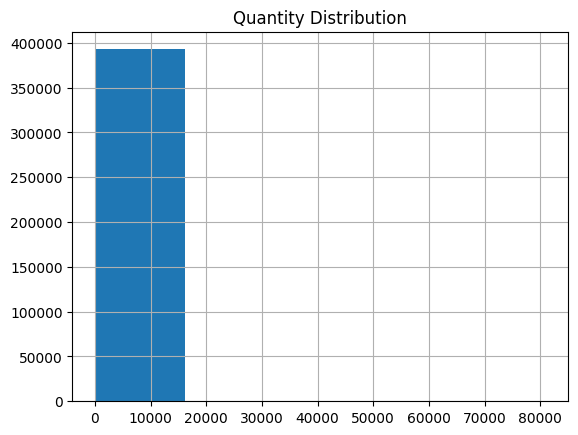

In [16]:
df['Quantity'].hist(bins=5)
plt.title('Quantity Distribution')
plt.show()


### Total Price Distribution

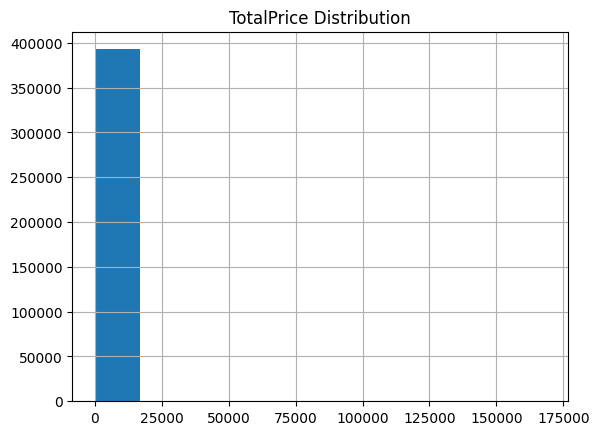

In [17]:
df['TotalPrice'].hist()
plt.title('TotalPrice Distribution')
plt.show()

## Categorical Analysis

### Top Products

In [18]:
df['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1713
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1389
LUNCH BAG RED RETROSPOT               1303
SET OF 3 CAKE TINS PANTRY DESIGN      1152
POSTAGE                               1099
LUNCH BAG  BLACK SKULL.               1078
PACK OF 72 RETROSPOT CAKE CASES       1050
Name: count, dtype: int64

### Top Countries

In [19]:
df['Country'].value_counts()

Country
United Kingdom          349203
Germany                   9025
France                    8326
EIRE                      7226
Spain                     2479
Netherlands               2359
Belgium                   2031
Switzerland               1841
Portugal                  1453
Australia                 1181
Norway                    1071
Italy                      758
Channel Islands            747
Finland                    685
Cyprus                     603
Sweden                     450
Austria                    398
Denmark                    380
Poland                     330
Japan                      321
Israel                     245
Unspecified                241
Singapore                  222
Iceland                    182
USA                        179
Canada                     151
Greece                     145
Malta                      112
United Arab Emirates        68
European Community          60
RSA                         57
Lebanon                     45


## Bivariate Analysis

### Total Price by Country

In [20]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

Country
United Kingdom          7285024.644
Netherlands              285446.340
EIRE                     265262.460
Germany                  228678.400
France                   208934.310
Australia                138453.810
Spain                     61558.560
Switzerland               56443.950
Belgium                   41196.340
Sweden                    38367.830
Japan                     37416.370
Norway                    36165.440
Portugal                  33375.840
Finland                   22546.080
Singapore                 21279.290
Channel Islands           20440.540
Denmark                   18955.340
Italy                     17483.240
Cyprus                    13502.850
Austria                   10198.680
Poland                     7334.650
Israel                     7215.840
Greece                     4760.520
Iceland                    4310.000
Canada                     3666.380
USA                        3580.390
Malta                      2725.590
Unspecified         

### Monthly Sales Trend

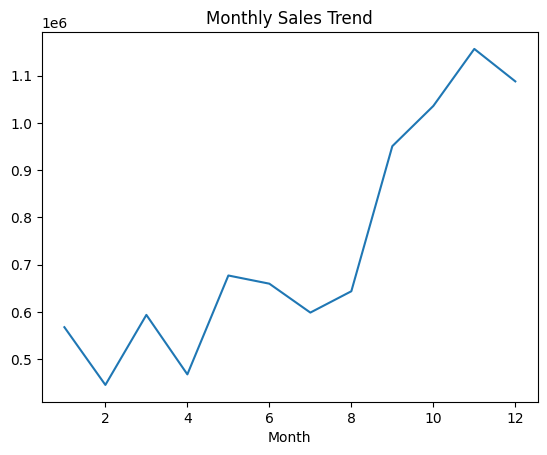

In [21]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.show()

<Axes: xlabel='InvoiceDate'>

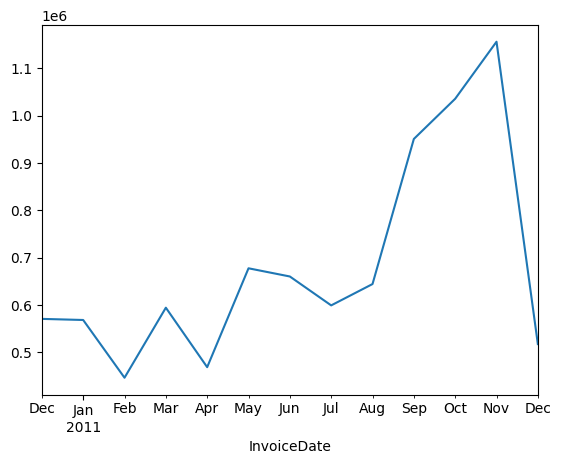

In [35]:
monthly = df.resample('ME', on='InvoiceDate')['TotalPrice'].sum()
monthly.plot()

### Trend + Seasonality Decomposition

### Customer Analysis

### Top Customers

In [23]:
df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: TotalPrice, dtype: float64

## Outlier Detection

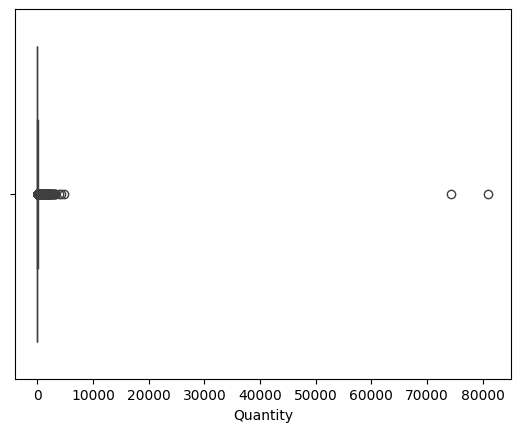

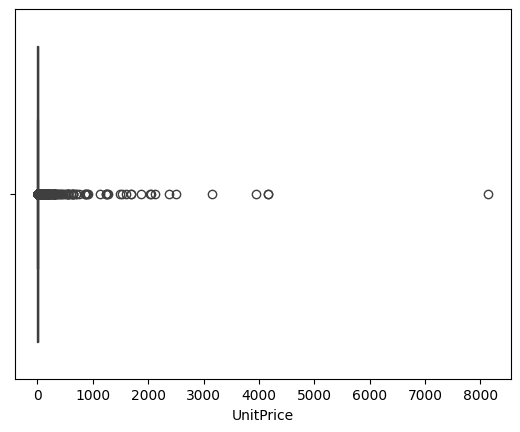

In [24]:
sns.boxplot(x=df['Quantity'])
plt.show()

sns.boxplot(x=df['UnitPrice'])
plt.show()

### Cap Outliers (Winsorization)

In [26]:
def remove_outliers_iqr_columns(df, columns):
    df_clean = df.copy()
    
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        before = len(df_clean)
        
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ]
        
        after = len(df_clean)
        print(f"{col}: Removed {before - after} outliers")
    
    return df_clean

In [27]:
df_iqr = remove_outliers_iqr_columns(df, ['Quantity', 'UnitPrice'])

Quantity: Removed 25616 outliers
UnitPrice: Removed 33842 outliers


### Z-SCORE METHOD

In [29]:
from scipy.stats import zscore
import numpy as np

def remove_outliers_zscore_columns(df, columns, threshold=3):
    df_clean = df.copy()
    
    z_scores = np.abs(zscore(df_clean[columns]))
    
    filtered_df = df_clean[(z_scores < threshold).all(axis=1)]
    
    print(f"Removed {len(df_clean) - len(filtered_df)} rows using Z-score")
    
    return filtered_df

In [30]:
df_z = remove_outliers_zscore_columns(df, ['Quantity', 'UnitPrice'])

Removed 607 rows using Z-score


In [32]:
df[['Quantity','UnitPrice']].describe()

# Skewness & Kurtosis
df[['Quantity','UnitPrice']].agg(['skew','kurtosis'])

,Quantity,UnitPrice
skew,407.345663,202.740861
kurtosis,175940.085113,57398.335042


### Correlation Matrix

In [33]:
df[['Quantity','UnitPrice','TotalPrice']].corr()

,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
TotalPrice,0.914451,0.081619,1.000000
